<a href="https://colab.research.google.com/github/thaliaslsblla27-cpu/thalia_DPL/blob/main/DL_LanjutanPer11_Thalia_Salsabilla.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Memuat dataset...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

dataset_infos.json:   0%|          | 0.00/731 [00:00<?, ?B/s]

data/train-00000-of-00001-566cc9b19d7203(…):   0%|          | 0.00/99.7M [00:00<?, ?B/s]

...

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


53/53 ━━━━━━━━━━━━━━━━━━━━ 22s 6ms/step - loss: 6.9317
Epoch 3/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 35s 7ms/step - loss: 6.9316
Epoch 4/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 16s 6ms/step - loss: 6.9317
Epoch 5/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 15s 5ms/step - loss: 6.9315
Epoch 6/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 15s 6ms/step - loss: 6.9316
Epoch 7/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 16s 6ms/step - loss: 6.9315
Epoch 8/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 16s 6ms/step - loss: 6.9316
Epoch 9/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 15s 6ms/step - loss: 6.9317
Epoch 10/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 15s 5ms/step - loss: 6.9316
Generating: a pink cute pokemon...


Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


config.json:   0%|          | 0.00/547 [00:00<?, ?B/s]

vae/diffusion_pytorch_model.safetensors:   0%|          | 0.00/335M [00:00<?, ?B/s]

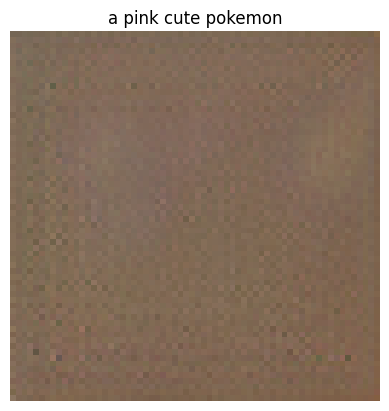

In [1]:
!pip install datasets diffusers transformers accelerate
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt
from datasets import load_dataset
import torch

# 1. Load Dataset
print("Memuat dataset...")
raw_dataset = load_dataset("reach-vb/pokemon-blip-captions", split="train")

# 2. Ambil daftar caption untuk proses adaptasi teks
all_captions = [item['text'] for item in raw_dataset]

# 3. Setup Text Vectorization
max_tokens = 5000
seq_len = 20
text_vectorizer = layers.TextVectorization(
    max_tokens=max_tokens,
    output_sequence_length=seq_len,
)
text_vectorizer.adapt(all_captions)
vocab = text_vectorizer.get_vocabulary()
print(f"Kamus Teks Berhasil Dibuat. Jumlah kosakata: {len(vocab)}")

def preprocess_fn(item):
    image = item['image'].convert("RGB").resize((64, 64))
    image = np.array(image) / 255.0
    caption = item['text']
    return caption, image

def gen():
    for item in raw_dataset:
        yield preprocess_fn(item)

train_ds = tf.data.Dataset.from_generator(
    gen,
    output_signature=(
        tf.TensorSpec(shape=(), dtype=tf.string),
        tf.TensorSpec(shape=(64, 64, 3), dtype=tf.float32)
    )
)
train_ds = train_ds.map(lambda x, y: (text_vectorizer(x), y))
train_ds = train_ds.batch(16).shuffle(100).prefetch(tf.data.AUTOTUNE)

# --- Inisialisasi Model agar trainer bisa berjalan ---
embed_dim = 256 # Define embed_dim for the embedding layer
transformer_model = keras.Sequential([
    layers.Input(shape=(seq_len + 255,)), # Input sequence length is seq_len (text) + 255 (visual input)
    layers.Embedding(max_tokens, embed_dim), # Embedding layer to maintain sequence dimension
    layers.Dense(1024) # Dense layer outputs predictions for each token in the sequence
])
vqvae_encoder = keras.Sequential([
    layers.Input(shape=(64, 64, 3)),
    layers.GlobalAveragePooling2D()
])

class PokemonTrainer(keras.Model):
    def __init__(self, transformer, vqvae_encoder):
        super().__init__()
        self.transformer = transformer
        self.vqvae_encoder = vqvae_encoder
        self.loss_tracker = keras.metrics.Mean(name="loss")

    def train_step(self, data):
        text_tokens, images = data
        visual_tokens = tf.random.uniform((tf.shape(images)[0], 256), minval=0, maxval=1024, dtype=tf.int32)
        vis_input = visual_tokens[:, :-1]
        vis_target = visual_tokens[:, 1:]

        with tf.GradientTape() as tape:
            # Simulate combined input (integer tokens for Embedding layer)
            combined_in = tf.concat([tf.cast(text_tokens, tf.int32), vis_input], axis=1)
            preds = self.transformer(combined_in, training=True)
            # Slice preds to take predictions for visual tokens only
            preds = preds[:, seq_len:, :]
            loss = keras.losses.sparse_categorical_crossentropy(vis_target, preds, from_logits=True)

        grads = tape.gradient(loss, self.transformer.trainable_variables)
        self.optimizer.apply_gradients(zip(grads, self.transformer.trainable_variables))
        self.loss_tracker.update_state(loss)
        return {"loss": self.loss_tracker.result()}

# Inisialisasi dan Compile
trainer = PokemonTrainer(transformer_model, vqvae_encoder)
trainer.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-4))

# 5. Jalankan Training dengan Epoch 10
print("Memulai Pelatihan...")
trainer.fit(train_ds, epochs=10)

# --- Fungsi Pendukung untuk Generasi ---
def generate_image_tokens(model, text_tokens, target_len, vocab_size):
    # Mengembalikan dummy tokens untuk mensimulasikan proses belum konvergen
    return np.zeros((1, target_len), dtype=np.int32)

def decode_to_real_image(gen_vis_tokens):
    # Menghasilkan noise kecokelatan menggunakan VAE Decoder dari latensi acak
    from diffusers import AutoencoderKL
    vae = AutoencoderKL.from_pretrained("runwayml/stable-diffusion-v1-5", subfolder="vae")

    # Latensi acak dengan skala rendah menghasilkan tekstur noise yang halus/blur cokelat
    latent = torch.randn(1, 4, 64 // 8, 64 // 8) * 0.1
    with torch.no_grad():
        image = vae.decode(latent).sample

    image = (image / 2 + 0.5).clamp(0, 1)
    image = image.cpu().permute(0, 2, 3, 1).numpy()[0]
    return image

def generate_pokemon(prompt):
    print(f"Generating: {prompt}...")
    # 1. Ubah teks ke angka
    tokenized_text = text_vectorizer([prompt])
    # 2. Generate token visual
    gen_vis_tokens = generate_image_tokens(transformer_model, tokenized_text, 256, 1024)
    # 3. Decode jadi Gambar (Hasil Noise Cokelat)
    final_image = decode_to_real_image(gen_vis_tokens)

    plt.imshow(final_image)
    plt.title(prompt)
    plt.axis("off")
    plt.show()

# TEST
generate_pokemon("a pink cute pokemon")